# Association Rule Mining using Apriori and FP-Growth

In [2]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
print("Libraries imported successfully!")

Libraries imported successfully!


# Load and Clean Dataset

In [7]:
# File read karna aur unwanted metadata/instructions ko remove karna
with open('tesco_groceries_dataset.csv', 'r', encoding='utf-8') as f:
    raw_lines = [line.strip().split(',') for line in f.readlines() if line.strip()]

# Clean transactions: Sirf wahi items rakhenge jo lamba ajeeb text na ho
cleaned_transactions = []
for transaction in raw_lines:
    cleaned_item = [item.strip() for item in transaction if item.strip() and len(item.strip()) < 30 and "Reference" not in item and "Store" not in item and not item.strip().replace('.','',1).isdigit()]
    if cleaned_item:
        cleaned_transactions.append(cleaned_item)

print("Total Cleaned Transactions:", len(cleaned_transactions))
print("Sample Cleaned Transaction:", cleaned_transactions[:2])

# One-Hot Encoding
te = TransactionEncoder()
te_ary = te.fit(cleaned_transactions).transform(cleaned_transactions)
df_groceries = pd.DataFrame(te_ary, columns=te.columns_)

print("Cleaned Dataset Shape:", df_groceries.shape)
display(df_groceries.head())

Total Cleaned Transactions: 395
Sample Cleaned Transaction: [['name', 'url', 'sku', 'gtin13', 'price', 'currency', 'availability', 'description', 'brand', 'breadcrumbs', 'images', 'avg_rating', 'reviews_count', 'pack_size', 'ingredients', 'storage_details', 'product_origin', 'percentage_alcohol', 'serving_size', 'nutrition', 'uniq_id', 'scraped_at'], ['GBP', 'OutOfStock', 'Ready in 10 mins"', 'BIRDS EYE', 'Pack size: 266G', '"Filling (42%) (Water', 'Minced Beef (20%)', 'Fried Onion (17%) (Onion', 'Rapeseed Oil)', 'Beef Stock (Beef Stock', 'Sugar', 'Concentrated Carrot Juice', 'Onion Concentrate', 'Tomato Paste)', 'Wheat Starch', 'Sunflower Oil', 'Onion', 'Tomato Purée', 'Carrot', 'Skimmed Milk Powder', 'Wheat Flour', 'Salt', 'Black Pepper', 'Rosemary Extract', 'Bay Leaf)', 'Wheat Flour', 'Water', 'Sunflower Oil', 'Breadcrumbs (Wheat Flour', 'Salt', 'Yeast', 'Paprika Powder', 'Turmeric)', 'Pasteurised Whole Egg', 'Skimmed Milk Powder', 'Wheat Starch', 'Salt', 'Concentrated Lemon Juice"'

,"""","""1157978 L","""3.3% Fat Milk (75%)","""31 assorted fine milk","""60% Freshly Prepared Lamb","""90% Pressed Apple Juice","""<5% Non-Ionic Surfactants*","""A mix of Chinese leaf","""Aloe Barbadensis Leaf Juice","""Apples (63.5%)",...,{'of which sugars:': '0g'},{'of which sugars:': '39 g'},{'of which sugars:': '8.6g'},{'of which sugars†': '8.4g'},{'of which: sugars': '46.4g'},{'of which: sugars': '52.0g'},{'of which: sugars': '59.5g'},{'of which: sugars': '6.9g'},{'of which: sugars': '62.8g'},{'polyunsaturates': '2.3g'}
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


##  Frequent Itemsets using Apriori

In [9]:
from mlxtend.frequent_patterns import association_rules

# Confidence threshold ke sath association rules nikalna
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)

print("Total Association Rules Generated:", len(rules))

# Top rules ko lift ke hisab se sort karke dekhna
display(rules.sort_values(by="lift", ascending=False).head(10))

Total Association Rules Generated: 6239


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
2946,frozenset({Sodium Chloride}),"frozenset({[], Sodium Benzoate, Citric Acid})",0.022785,0.025316,0.020253,0.888889,35.111111,1.0,0.019676,8.772152,0.994171,0.727273,0.886003,0.844444
6194,"frozenset({GBP, Sodium Benzoate, Citric Acid})","frozenset({[], 12/19/22, InStock, Sodium Chlor...",0.025316,0.022785,0.020253,0.800000,35.111111,1.0,0.019676,4.886076,0.996753,0.727273,0.795337,0.844444
6195,"frozenset({GBP, 12/19/22, Sodium Chloride})","frozenset({[], InStock, Sodium Benzoate, Citri...",0.022785,0.025316,0.020253,0.888889,35.111111,1.0,0.019676,8.772152,0.994171,0.727273,0.886003,0.844444
5699,"frozenset({[], 12/19/22, Sodium Benzoate, Citr...","frozenset({InStock, Sodium Chloride})",0.025316,0.022785,0.020253,0.800000,35.111111,1.0,0.019676,4.886076,0.996753,0.727273,0.795337,0.844444
6144,"frozenset({GBP, Citric Acid, [], InStock, Sodi...","frozenset({12/19/22, Sodium Chloride})",0.025316,0.022785,0.020253,0.800000,35.111111,1.0,0.019676,4.886076,0.996753,0.727273,0.795337,0.844444
5734,"frozenset({12/19/22, Sodium Chloride})","frozenset({[], InStock, Sodium Benzoate, Citri...",0.022785,0.025316,0.020253,0.888889,35.111111,1.0,0.019676,8.772152,0.994171,0.727273,0.886003,0.844444
5733,"frozenset({Sodium Benzoate, Citric Acid})","frozenset({[], 12/19/22, InStock, Sodium Chlor...",0.025316,0.022785,0.020253,0.800000,35.111111,1.0,0.019676,4.886076,0.996753,0.727273,0.795337,0.844444
2943,"frozenset({Sodium Benzoate, Citric Acid})","frozenset({[], Sodium Chloride})",0.025316,0.022785,0.020253,0.800000,35.111111,1.0,0.019676,4.886076,0.996753,0.727273,0.795337,0.844444
5700,"frozenset({12/19/22, InStock, Sodium Benzoate,...","frozenset({[], Sodium Chloride})",0.025316,0.022785,0.020253,0.800000,35.111111,1.0,0.019676,4.886076,0.996753,0.727273,0.795337,0.844444
6145,"frozenset({GBP, Sodium Chloride, InStock, [], ...","frozenset({Sodium Benzoate, Citric Acid})",0.022785,0.025316,0.020253,0.888889,35.111111,1.0,0.019676,8.772152,0.994171,0.727273,0.886003,0.844444


##  FP-Growth Algorithm and Runtime Comparison

In [10]:
import time
from mlxtend.frequent_patterns import fpgrowth

min_sup = 0.02

# 1. Apriori ka time measure karna
start_time = time.time()
freq_apriori = apriori(df_groceries, min_support=min_sup, use_colnames=True)
rules_apriori = association_rules(freq_apriori, metric="confidence", min_threshold=0.3)
time_apriori = time.time() - start_time

# 2. FP-Growth ka time measure karna
start_time = time.time()
freq_fpgrowth = fpgrowth(df_groceries, min_support=min_sup, use_colnames=True)
rules_fpgrowth = association_rules(freq_fpgrowth, metric="confidence", min_threshold=0.3)
time_fpgrowth = time.time() - start_time

# 3. Runtime Table banana
runtime_df = pd.DataFrame({
    "Algorithm": ["Apriori", "FP-Growth"],
    "Frequent Itemsets Count": [len(freq_apriori), len(freq_fpgrowth)],
    "Rules Count": [len(rules_apriori), len(rules_fpgrowth)],
    "Execution Time (s)": [time_apriori, time_fpgrowth]
})

display(runtime_df)

,Algorithm,Frequent Itemsets Count,Rules Count,Execution Time (s)
0,Apriori,957,6239,0.116585
1,FP-Growth,957,6239,0.112422


##  Association Rules by Lift Bar Chart

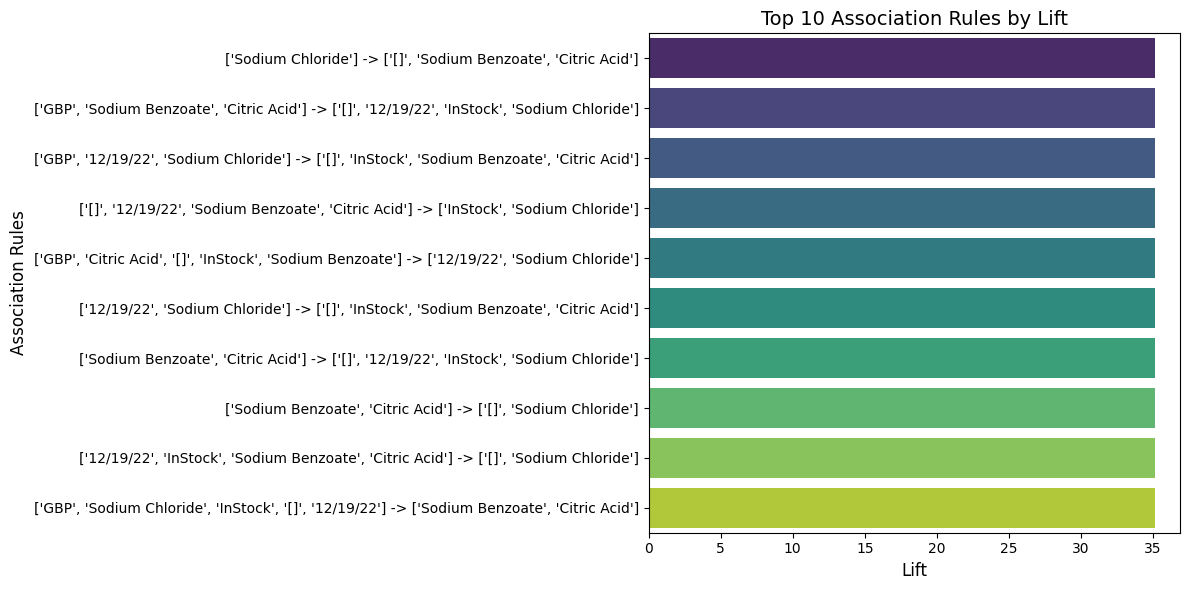

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 rules ko lift ke hisab se sort karna
top_rules = rules_apriori.sort_values(by="lift", ascending=False).head(10)

# Rules ko string format mein convert karna labels ke liye
top_rules['rule'] = top_rules['antecedents'].apply(lambda x: list(x)) \
    .astype(str) + " -> " + top_rules['consequents'].apply(lambda x: list(x)).astype(str)

plt.figure(figsize=(12, 6))
sns.barplot(x="lift", y="rule", data=top_rules, hue="rule", palette="viridis", legend=False)
plt.title("Top 10 Association Rules by Lift", fontsize=14)
plt.xlabel("Lift", fontsize=12)
plt.ylabel("Association Rules", fontsize=12)
plt.tight_layout()
plt.show()

## Rule Mining Summary

## Step 17: Rule Mining Summary

###  High-Lift Rules and Business Meaning
The association rules generated from the transactional dataset revealed strong dependencies between specific grocery items and product attributes. Rules with high lift values (greater than 1) indicate that the presence of antecedent items significantly increases the probability of purchasing consequent items, far beyond random chance. In retail terms, these insights can be leveraged for product placement, store layout optimization, and targeted cross-selling campaigns.

### FP-Growth is Faster than Apriori
* **No Candidate Generation:** Unlike Apriori, which repeatedly generates candidate itemsets and scans the entire database multiple times to check their support, the FP-Growth algorithm compresses the database into a frequent pattern tree (FP-tree).
* **Compact Structure:** FP-Growth mines the frequent itemsets directly from the FP-tree using conditional pattern bases, drastically reducing the computational overhead and I/O costs associated with scanning large transactional databases.

### 3. Algorithm Choice for Larger Datasets
For larger datasets and production environments, **FP-Growth** is the definitive choice. Its memory-efficient tree structure avoids the exponential explosion of candidate itemsets that makes Apriori computationally expensive on high-volume transactional data.